# Summarizing complex landscapes

In the previous section, we illustrate of how to infer a complete
combinatorial landscape from empirical data using either `VCregression` or `SeqDEFT`. 
In this section, we illustrate how to obtain low-dimensional summary statistics of the
inferred landscapes that characterize the complexity and patterns of genetic interactions
across the different sequence positions. We do so by computing the variance explained by
genetic interactions of different orders, involving each possible site and pairs of sites.


## GB1 protein landscape

In this section, we first show how we can use `gpmap-tools` to understand the complexity and patterns of genetic interactions across multiple sites in a previously inferred genotype-phenotype map (GB1) using `VCregression` and [previously published high throughput experimental data](https://doi.org/10.7554/eLife.16965).

In [46]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gpmap.datasets import DataSet
from gpmap.summary import GPmapSummarizer

We use the inferred complete combinatorial landscape as provided in `DataSet`s

In [8]:
gb1 = DataSet('gb1')
gb1.landscape

,y
seq,
AAAA,0.296301
AAAC,-2.713474
AAAD,-2.912992
AAAE,-4.548719
AAAF,-3.276738
...,...
YYYS,-4.662925
YYYT,-3.223102
YYYV,-3.001718


Firts, we define a `GPmapSummarizer` object with the configuration of sequence space and the associated functional values for every possible sequence `f`. 

> **Note**: Function values must be provided for sequences in alphabetical order.

In [9]:
gb1s = GPmapSummarizer(n_alleles=20, seq_length=4, f=gb1.landscape['y'].values)

### How to compute the variance components of interactions of order `k`

Now, we only need to call the method `calc_V_k_variance_components` to obtain a `pd.DataFrame` with the total and percentage variance explained by interactions of every possible order

In [10]:
v_k_vcs = gb1s.calc_V_k_variance_components()
v_k_vcs

,k,variance,variance_perc,variance_perc_cum
0,1,180067.068327,52.811580,52.811580
1,2,128538.741722,37.698921,90.510501
2,3,31449.759748,9.223849,99.734350
3,4,905.762731,0.265650,100.000000


which can be easily represented graphically as follows

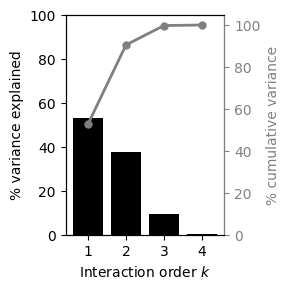

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(3, 3))

# Plot percentage variance explained
axes.bar(x=v_k_vcs["k"], height=v_k_vcs["variance_perc"], color="black")
axes.set(
    xlabel="Interaction order $k$",
    ylabel="% variance explained",
    xticks=np.arange(1, 10),
    ylim=(0, 100),
)

# Plot cumulative percentage variance explained
axes = axes.twinx()
axes.scatter(v_k_vcs["k"], v_k_vcs["variance_perc_cum"], color="grey", s=25)
axes.plot(v_k_vcs["k"], v_k_vcs["variance_perc_cum"], color="grey", lw=2)
axes.tick_params(axis="y", colors="grey")
axes.spines["right"].set_color("grey")
axes.set(ylim=(0, 105))
axes.set_ylabel("% cumulative variance", color="grey")
fig.tight_layout()

However, this only provides information about the complexity of the landscape, but not about which sites are involved in more or less complex genetic interactions and whether interactions are widespread or happening between specific sets of sites. 

### How to compute the variance components of interactions involving a subsets of sites $U$

This can be done by calling the method `calc_V_U_variance_components` to obtain a `pd.DataFrame` with the total and percentage variance explained involving every possible combination of sites


In [19]:
v_U_vcs = gb1s.calc_V_U_variance_components()
v_U_vcs


,U,k,variance,variance_perc,variance_perc_cum
0,{0},1,28303.313131,8.301033,8.301033
1,{1},1,16149.051370,4.736329,13.037362
2,{2},1,77458.399775,22.717649,35.755012
3,{3},1,58156.304052,17.056569,52.811580
4,"{0, 1}",2,5138.287598,1.507000,54.318581
5,"{0, 2}",2,25776.797274,7.560035,61.878616
6,"{0, 3}",2,17682.891637,5.186187,67.064803
7,"{1, 2}",2,8761.142103,2.569541,69.634344
8,"{1, 3}",2,5422.459340,1.590344,71.224688
9,"{2, 3}",2,65757.163770,19.285813,90.510501


Whereas the number of possible combinations is relatively small in this case, it scales exponentially with sequence length, making it in practical in other cases to interpret the values in this `DataFrame` directly. Still, we can compute some useful aggregated statistics that we can represent easily as heatmaps.

### How to compute the variance explained by interactions of order `k` involving each site

`calc_sites_variance_perc` enables aggregation of these variances by whether they involve each possible site and the total number of sites involved in those genetic interactions. 

In [21]:
sites = gb1s.calc_sites_variance_perc(v_U_vcs).T
sites

,1,2,3,4
0,8.301033,14.253222,7.386529,0.26565
1,4.736329,5.666886,3.713892,0.26565
2,22.717649,29.415389,8.439197,0.26565
3,17.056569,26.062344,8.131930,0.26565


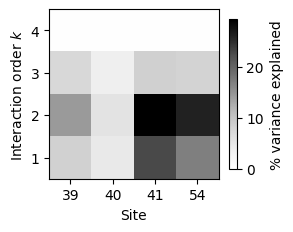

In [44]:
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
im = axes.imshow(
    sites.T.iloc[::-1, :],
    cmap="Greys",
    vmin=0,
)
axes.set(
    xticks=[0, 1, 2, 3],
    xticklabels=[39, 40, 41, 54],
    xlabel="Site",
    yticks=[0, 1, 2, 3],
    yticklabels=[1, 2, 3, 4][::-1],
    ylabel="Interaction order $k$",
    aspect='equal'
)
plt.colorbar(im, shrink=0.6, label='% variance explained')
fig.tight_layout()

This clearly shows that some sites (41 and 54) have a much larger contribution to the phenotypic variance than others (40), and that they contribute mostly through their additive, pairwise and even threeway interactions.

### How to compute the variance explained by interactions between every pair of sites

Another interesting way to aggregate the variance explain by every subset of sites $U$ is by computing the variance explain by interactions of any order involving a pair of sites. 


In [45]:
pairs = gb1s.calc_site_pairs_variance_perc(v_U_vcs)
pairs


,site1,site2,variance,variance_perc
0,0,1,12442.433333,7.733298
1,0,2,49192.407027,30.574370
2,0,3,40050.839230,24.892646
3,1,2,19654.479720,12.215774
4,1,3,15268.134797,9.489546
5,2,3,91714.303247,57.002842


We can arrange these values on a matrix and represent them in a heatmap

In [54]:
m = pd.pivot_table(
    pairs, index="site1", columns="site2", values="variance_perc"
)
m

site2,1,2,3
site1,,,
0,7.733298,30.574370,24.892646
1,NaN,12.215774,9.489546
2,NaN,NaN,57.002842


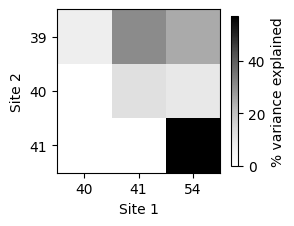

In [57]:
fig, axes = plt.subplots(1, 1, figsize=(3, 3))
im = axes.imshow(
    m,
    cmap="Greys",
    vmin=0,
)
axes.set(
    xticks=[0, 1, 2],
    xlabel="Site 1",
    yticks=[0, 1, 2],
    xticklabels=[40, 41, 54],
    yticklabels=[39, 40, 41],
    ylabel="Site 2",
    aspect="equal",
)
plt.colorbar(im, shrink=0.6, label="% variance explained")
fig.tight_layout()

This plot clearly shows that sites 41 and 54 interact strongly with each other, but also with position 39.

## Shine-Dalgarno fitness landscape

In the previous example, the total number of subsets of sites $U$ is still relatively small given the short sequence length. To better illustrate the usefulness of this approach, we will use a  9-nucleotide long complete combinatorial landscape inferred with `VCregression` from [previously published high throughput experimental data](https://genome.cshlp.org/content/30/5/711) in the *dmsC* gene context. The inferred landscape is also available as a `DataSet` for illustration purposes.


In [58]:
sd = DataSet('dmsc')
sd.landscape

,f
AAAAAAAAA,0.563857
AAAAAAAAC,0.701511
AAAAAAAAG,0.619188
AAAAAAAAU,0.628772
AAAAAAACA,0.594683
...,...
UUUUUUUGU,0.615910
UUUUUUUUA,0.539058
UUUUUUUUC,0.548782
UUUUUUUUG,0.536610


Lets start again by defining the `GPmapSummarizer` object and compute the variance explained by every possible subset of sites

In [59]:
sds = GPmapSummarizer(n_alleles=4, seq_length=9, f=sd.landscape["f"].values)

In [60]:
v_U_vcs = sds.calc_V_U_variance_components()
v_U_vcs

,U,k,variance,variance_perc,variance_perc_cum
0,{0},1,1574.656812,5.500762,5.500762
1,{1},1,2687.622462,9.388695,14.889458
2,{2},1,2312.377111,8.077847,22.967305
3,{3},1,1806.662119,6.311229,29.278533
4,{4},1,1051.784760,3.674209,32.952742
...,...,...,...,...,...
506,"{0, 1, 2, 4, 5, 6, 7, 8}",8,2.485503,0.008683,99.956748
507,"{0, 1, 3, 4, 5, 6, 7, 8}",8,2.545558,0.008892,99.965641
508,"{0, 2, 3, 4, 5, 6, 7, 8}",8,2.358090,0.008238,99.973878
509,"{1, 2, 3, 4, 5, 6, 7, 8}",8,2.796804,0.009770,99.983648


We can see that the number of components now is much larger than before, so we really need to aggregate these components in a meaningful way to obtain low-dimensional summary statistics reflecting the patterns of genetic interactions in the inferred genotype-phenotype map.

### How to compute the variance explained by interactions of order `k` involving each site

In [61]:
sites = sds.calc_sites_variance_perc(v_U_vcs)
sites

,0,1,2,3,4,5,6,7,8
1,5.500762,9.388695,8.077847,6.311229,3.674209,2.277808,1.837005,0.835968,0.399951
2,6.390370,10.088863,10.262287,8.163453,6.898441,4.512101,3.034212,1.908863,1.153861
3,5.799007,8.710946,10.348244,11.095941,10.542178,8.887247,5.887798,3.522035,2.133580
4,2.999159,4.047676,4.776184,5.714224,5.930684,5.423643,4.125461,2.856694,1.932568
5,1.208228,1.508030,1.640607,1.763638,1.809694,1.735487,1.502939,1.196867,0.925827
6,0.441740,0.488117,0.516701,0.522051,0.525214,0.525015,0.496194,0.446754,0.389411
7,0.187551,0.194456,0.197175,0.198214,0.199869,0.199935,0.199599,0.192142,0.179375
8,0.070391,0.071923,0.071268,0.071478,0.071555,0.071555,0.071691,0.071658,0.069766
9,0.016352,0.016352,0.016352,0.016352,0.016352,0.016352,0.016352,0.016352,0.016352


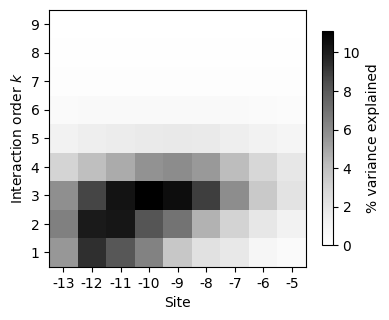

In [65]:
orders = np.arange(1, 10)
positions = np.arange(-13, -4)
ticks = np.arange(9)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
im = axes.imshow(
    sites.iloc[::-1, :],
    cmap="Greys",
    vmin=0,
)
axes.set(
    xticks=ticks,
    xticklabels=positions,
    xlabel="Site",
    yticks=ticks,
    yticklabels=orders[::-1],
    ylabel="Interaction order $k$",
    aspect="equal",
)
plt.colorbar(im, shrink=0.6, label="% variance explained")
fig.tight_layout()


This plot shows that whereas some positions have large additive and pairwise contributions, other sites have more context-dependent contributions to phenotypic variation, with the largest contributions arising from interactions of order 3 or higher.

### How to compute the variance explained by pairwise and higher order interactions between every pair of sites

In this example, we do an finer aggregation and separate the variance explained by pairwise and higher order interactions between pairs of sites on the upper and lower triangular parts of the heatmap representation.


In [88]:
pairs_pw = sds.calc_site_pairs_variance_perc(v_U_vcs.loc[v_U_vcs['k'] == 2, :])
pairs_ho = sds.calc_site_pairs_variance_perc(v_U_vcs, min_k=3)

m_bottom = pairs_pw.pivot(index="site1", columns="site2", values="variance_perc")
m_bottom = m_bottom.reindex(ticks).T.reindex(ticks).fillna(0)
m_top = pairs_ho.pivot(index='site1', columns='site2', values='variance_perc')
m_top = m_top.reindex(ticks).T.reindex(ticks).fillna(0).T
m = m_top + m_bottom
m

site2,0,1,2,3,4,5,6,7,8
site1,,,,,,,,,
0,0.000000,20.235400,19.297067,12.736994,8.528527,7.706634,5.887429,4.593244,3.814681
1,8.562998,0.000000,28.937652,22.225871,13.779223,9.638418,7.624355,5.565630,4.245642
2,9.734242,13.710318,0.000000,28.779777,20.837386,13.780875,7.749691,5.786126,4.398405
3,1.380292,9.409153,6.562947,0.000000,31.867450,23.175051,12.769771,6.189255,5.449330
4,1.371878,2.865711,4.951972,7.331872,0.000000,31.061032,19.615363,10.645316,6.161446
5,1.202204,1.320697,2.437803,3.856483,4.213326,0.000000,21.838515,13.053678,7.791366
6,1.367760,1.333584,0.959993,1.554637,3.281415,1.401816,0.000000,13.716746,7.937204
7,0.635882,0.887281,0.527592,0.344046,1.860773,1.435976,1.094349,0.000000,9.259406
8,0.129675,0.408224,0.274862,0.711385,0.446727,1.349362,0.584660,0.498108,0.000000


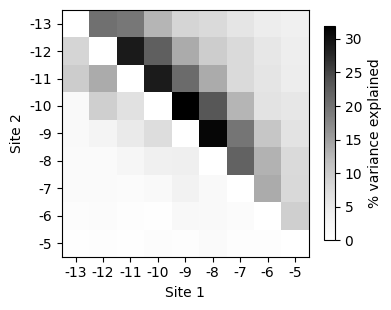

In [89]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
im = axes.imshow(
    m,
    cmap="Greys",
    vmin=0,
)
axes.set(
    xticks=ticks,
    xlabel="Site 1",
    yticks=ticks,
    xticklabels=positions,
    yticklabels=positions,
    ylabel="Site 2",
    aspect="equal",
)
plt.colorbar(im, shrink=0.6, label="% variance explained")
fig.tight_layout()


Overall, this summary plots show that positions in the Shine-Dalgarno sequence tend to interact mostly with adjacent positions. Moreover, higher order interactions can involve sites that are further appart from each other in the primary sequence.